<a href="https://colab.research.google.com/github/ekaagragupta/coreGen/blob/main/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 0, Loss: 2.3027, Accuracy: 0.1051
Epoch 10, Loss: 2.2962, Accuracy: 0.2100
Epoch 20, Loss: 2.2845, Accuracy: 0.3001
Epoch 30, Loss: 2.2594, Accuracy: 0.3701
Epoch 40, Loss: 2.2053, Accuracy: 0.3916
Test Accuracy: 0.4427857142857143


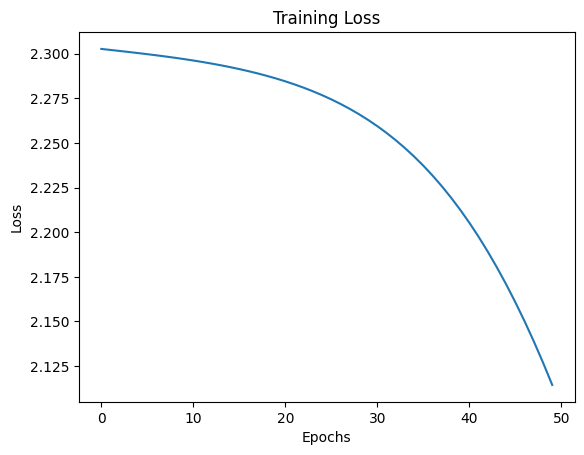

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data / 255.0
y = mnist.target.astype(int)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot encoding (compatible with all sklearn versions)
encoder = OneHotEncoder(sparse_output=False)
y_train_oh = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_oh = encoder.transform(y_test.reshape(-1, 1))

# Initialize
np.random.seed(42)
input_size = 784
hidden_size = 64
output_size = 10

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

# Activation
def relu(x):
    return np.maximum(0, x)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Forward
def forward(X):
    z1 = X.dot(W1) + b1
    a1 = relu(z1)
    z2 = a1.dot(W2) + b2
    a2 = softmax(z2)
    return z1, a1, z2, a2

# Loss
def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    return -np.sum(y_true * np.log(y_pred + 1e-8)) / m

# Accuracy
def accuracy(y_true, y_pred):
    return np.mean(np.argmax(y_pred, axis=1) == np.argmax(y_true, axis=1))

# Backward
def backward(X, y_true, z1, a1, a2):
    m = X.shape[0]

    dz2 = (a2 - y_true) / m
    dW2 = a1.T.dot(dz2)
    db2 = np.sum(dz2, axis=0, keepdims=True)

    da1 = dz2.dot(W2.T)
    dz1 = da1 * (z1 > 0)

    dW1 = X.T.dot(dz1)
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

# Training
learning_rate = 0.1
epochs = 50
losses = []

for i in range(epochs):
    z1, a1, z2, a2 = forward(X_train)

    loss = compute_loss(y_train_oh, a2)
    losses.append(loss)

    dW1, db1, dW2, db2 = backward(X_train, y_train_oh, z1, a1, a2)

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if i % 10 == 0:
        acc = accuracy(y_train_oh, a2)
        print(f"Epoch {i}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# Test
_, _, _, test_pred = forward(X_test)
test_acc = accuracy(y_test_oh, test_pred)
print("Test Accuracy:", test_acc)

# Plot loss
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()